# Digit Recognizer (Computer Vision)

## Import and test kaggle dataset

In [22]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

In [23]:
# Download latest version of competition files
path = kagglehub.competition_download('digit-recognizer')

print("Path to competition files:", path)

Path to competition files: C:\Users\Joey\.cache\kagglehub\competitions\digit-recognizer


In [24]:
# import data and check shapes
train = pd.read_csv(path + '/train.csv')
test = pd.read_csv(path + '/test.csv')
sample_submission = pd.read_csv(path + '/sample_submission.csv')
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (42000, 785)
Test shape: (28000, 784)
Sample submission shape: (28000, 2)


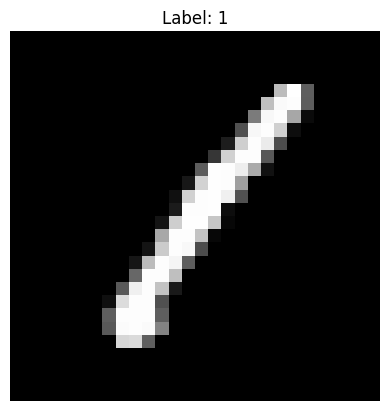

In [25]:
# Draw an image form the training set 1st row
image = train.iloc[0, 1:].values.reshape(28, 28) # 28 pixels height & 28 pixels width; 28*28 = 784 pixels
plt.imshow(image, cmap='gray')
plt.title(f"Label: {train.iloc[0, 0]}")
plt.axis('off')
plt.show()

## Exploratory Data Analysis

In [26]:
'''
Exploratory Data Analysis (EDA)
'''
train['label'].describe()

count    42000.000000
mean         4.456643
std          2.887730
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max          9.000000
Name: label, dtype: float64

In [27]:
'''
missing values; check if any missing values in train and test sets
'''
print("Missing values in train set:\n", train.isnull().sum().any())
print("Missing values in test set:\n", test.isnull().sum().any())

Missing values in train set:
 False
Missing values in test set:
 False


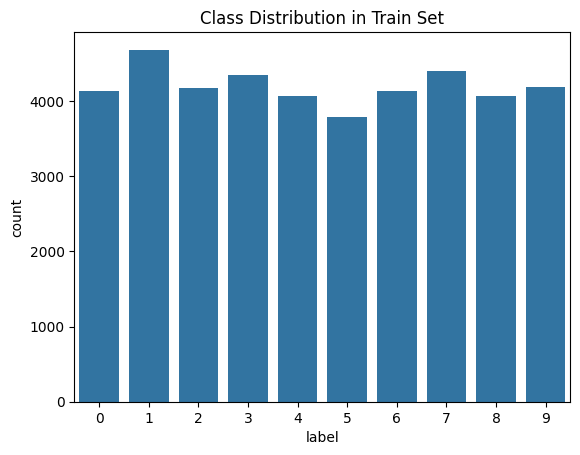

In [28]:
# Check class distribution for train set
sns.countplot(x='label', data=train)
plt.title("Class Distribution in Train Set")
plt.show()

## Train Convolution Nueral Network (CNN) Model

In [29]:
'''
Prepare TrainingData
'''

X = train.drop("label", axis=1).values / 255.0
y = train["label"].values

# Convert to tensors
X_tensor = torch.tensor(X, dtype=torch.float32).reshape(-1, 1, 28, 28) # Reshape to (N, C, H, W) for CNN; C=1 for grayscale
y_tensor = torch.tensor(y, dtype=torch.long)

dataset = TensorDataset(X_tensor, y_tensor)
dataset

In [30]:
# Train / Validation split
train_size = int(0.8 * len(dataset)) # 80% for training, 20% for validation
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [31]:
'''
Device; check if GPU is available
'''
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [32]:
'''
CNN Model

Architecture explanation:
- 2 convolutional layers with ReLU activations and max pooling to extract features from the images
- Fully connected layers to classify the extracted features into 10 classes (digits 0-9)

'''
class DigitCNN(nn.Module):
    def __init__(self):
        super(DigitCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            # Input channels = 1 (grayscale), Output channels = 32, Kernel size = 3x3, Padding = 1 (maintain spatial dimensions)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # Reduce spatial dimensions (28x28 to 14x14)

            # Input channels = 32, Output channels = 64, Kernel size = 3x3, Padding = 1 (maintain spatial dimensions)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(), # Flatten the output from conv layers to feed into fully connected layers
            nn.Linear(64 * 7 * 7, 128), # 64 channels * 7 height * 7 width after pooling
            nn.ReLU(),
            nn.Dropout(0.3), # Dropout for regularization
            nn.Linear(128, 10) # 10 output classes for digits 0-9
        )

    def forward(self, x):
        # Forward pass through convolutional layers
        x = self.conv_layers(x)
        # Forward pass through fully connected layers
        x = self.fc_layers(x)
        return x

model = DigitCNN().to(device)

In [33]:
'''
Loss and Optimizer

Adam uses adaptive learning rates for each parameter
'''
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [34]:
'''
Early Stopping Settings
'''
epochs = 30
patience = 5
best_val_loss = float("inf")
counter = 0
best_model_weights = copy.deepcopy(model.state_dict())

In [35]:
'''
Training Loop
'''
# Store losses for plotting
train_losses = []
val_losses = []

for epoch in range(epochs):

    # Training
    # ---------
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # reset gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward pass and optimization
        loss.backward()
        optimizer.step()

        # accumulate training loss
        train_loss += loss.item()

        # get predicted class and compare with true labels
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate average losses and accuracies
    train_acc = 100 * correct / total
    avg_train_loss = train_loss / len(train_loader)

    # Validation
    # ----------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    # No gradient calculation during validation
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            # check validation loss and accuracy
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            # get predicted class and compare with true labels
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()
    # Calculate average losses and accuracies
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )
    
    # Save losses for plotting
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Early Stopping Check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        print("Validation improved. Saving best model.")
    else:
        counter += 1
        print(f"No improvement ({counter}/{patience})")

        if counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1/30 | Train Loss: 0.9408 | Val Loss: 0.3316 | Train Acc: 73.13% | Val Acc: 90.52%
Validation improved. Saving best model.
Epoch 2/30 | Train Loss: 0.3233 | Val Loss: 0.2105 | Train Acc: 90.06% | Val Acc: 93.65%
Validation improved. Saving best model.
Epoch 3/30 | Train Loss: 0.2206 | Val Loss: 0.1474 | Train Acc: 93.31% | Val Acc: 95.52%
Validation improved. Saving best model.
Epoch 4/30 | Train Loss: 0.1670 | Val Loss: 0.1153 | Train Acc: 94.97% | Val Acc: 96.39%
Validation improved. Saving best model.
Epoch 5/30 | Train Loss: 0.1372 | Val Loss: 0.0964 | Train Acc: 95.95% | Val Acc: 97.00%
Validation improved. Saving best model.
Epoch 6/30 | Train Loss: 0.1170 | Val Loss: 0.0845 | Train Acc: 96.42% | Val Acc: 97.33%
Validation improved. Saving best model.
Epoch 7/30 | Train Loss: 0.1000 | Val Loss: 0.0745 | Train Acc: 97.00% | Val Acc: 97.63%
Validation improved. Saving best model.
Epoch 8/30 | Train Loss: 0.0906 | Val Loss: 0.0699 | Train Acc: 97.31% | Val Acc: 97.85%
Validati

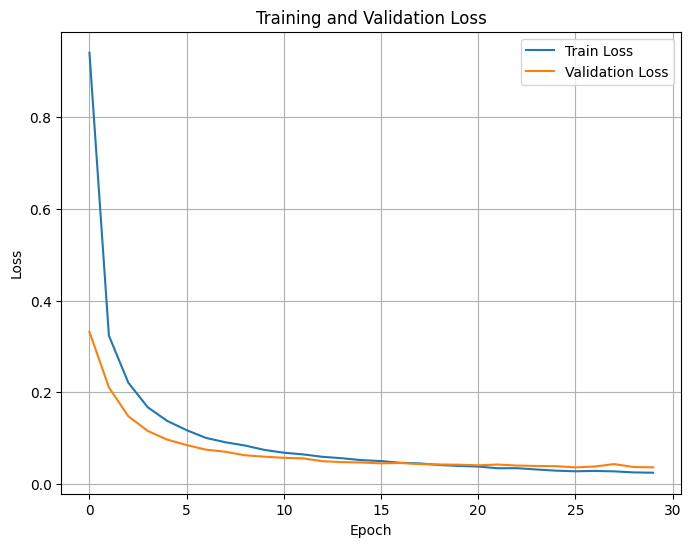

In [36]:
'''
Visualize Training and Validation Loss
'''
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
'''
Restore and save Best Model
'''
# Create model folder if it does not exist
os.makedirs("models", exist_ok=True)

# Restore best weights
model.load_state_dict(best_model_weights)
print("Best model restored.")

# Save best model inside models folder
save_path = "models/cnn_best_model.pth"
torch.save(model.state_dict(), save_path)

print(f"Best model saved to {save_path}")

Best model restored.
Best model saved to models/cnn_best_model.pth


## Predict using best CNN model on Test Data

In [38]:
'''
Load Test Data
'''

# Normalize and reshape
X_test = test.values / 255.0
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).reshape(-1, 1, 28, 28)

In [39]:
'''
Load model
'''
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DigitCNN().to(device)
model.load_state_dict(torch.load("models/cnn_best_model.pth", map_location=device))
model.eval()

DigitCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [40]:
'''
Make Predictions on Test Set
'''

predictions = []

with torch.no_grad():
    for i in range(0, len(X_test_tensor), 64):
        batch = X_test_tensor[i:i+64].to(device)

        outputs = model(batch)
        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.cpu().numpy())

In [41]:
'''
Check submission format
'''
print(sample_submission.head())

   ImageId  Label
0        1      0
1        2      0
2        3      0
3        4      0
4        5      0


In [42]:
'''
Create new submission file
'''

submission = pd.DataFrame({
    "ImageId": np.arange(1, len(predictions) + 1),
    "Label": predictions
})

submission.to_csv("submission.csv", index=False)
submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


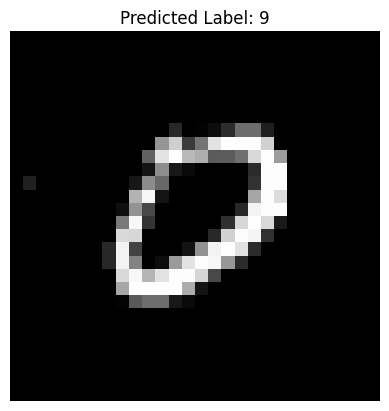

In [49]:
# Check image from test set
test_image = X_test_tensor[3].cpu().numpy().reshape(28, 28)
plt.imshow(test_image, cmap='gray')
plt.title(f"Predicted Label: {predictions[3]}")
plt.axis('off')
plt.show()